In [6]:
# 导入必要的库
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 读取Excel文件中（此数据已经完成初步筛选）
file_path = r'E:\dataname.xlsx'
data = pd.read_excel(file_path, sheet_name=1)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 定义位移列和影响因素列
displacement_cols = data.columns[0:4]  
factor_cols = data.columns[4:]         

scalers = {}  
data_scaled = pd.DataFrame(index=data.index)

for col in displacement_cols:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled[col] = scaler.fit_transform(data[[col]])
    scalers[col] = scaler  

for col in factor_cols:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled[col] = scaler.fit_transform(data[[col]])
    scalers[col] = scaler  

data_scaled = data_scaled.values

# 划分训练集和测试集（前80%为训练集，后20%为测试集）
train_size = int(len(data) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]


In [27]:
# 定义时间步
time_steps = 2

def create_sequences(data, time_steps, target_index):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])  
        y.append(data[i + time_steps, target_index])  
    return np.array(X), np.array(y)

# 使用第一个监测点的位移为预测目标
target_index = 3  # 第一个监测点位移在合并后的数据中是第一个列
X_train, y_train = create_sequences(train_data, time_steps, target_index)
X_test, y_test = create_sequences(test_data, time_steps, target_index)


Epoch 1/40
19/19 [==============================] - 4s 38ms/step - loss: 0.1600 - val_loss: 0.0807
Epoch 2/40
19/19 [==============================] - 0s 6ms/step - loss: 0.1107 - val_loss: 0.0584
Epoch 3/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0886 - val_loss: 0.0512
Epoch 4/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0753 - val_loss: 0.0410
Epoch 5/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0591 - val_loss: 0.0350
Epoch 6/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0466 - val_loss: 0.0297
Epoch 7/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0411 - val_loss: 0.0252
Epoch 8/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0354 - val_loss: 0.0212
Epoch 9/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0315 - val_loss: 0.0180
Epoch 10/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0272 - val_loss: 0.0157
Epoch 11/40
19/19 

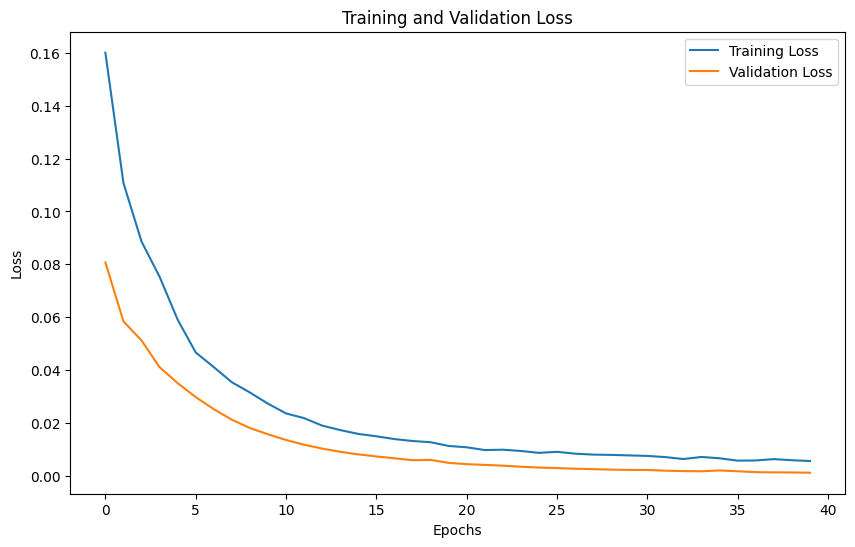

In [28]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
model = Sequential([
    LSTM(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3), 
    LSTM(15, return_sequences=False,kernel_regularizer=l2(0.002)),
    Dropout(0.3), 
    Dense(25),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=40, batch_size=64, validation_data=(X_test, y_test), verbose=1)
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [29]:
# 进行预测
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 将预测结果逆归一化，仅对第二个监测点的位移进行逆归一化
train_predict = scalers[displacement_cols[3]].inverse_transform(np.concatenate([train_predict] * len(displacement_cols), axis=1))[:, 0]
test_predict = scalers[displacement_cols[3]].inverse_transform(np.concatenate([test_predict] * len(displacement_cols), axis=1))[:, 0]

# 将真实值逆归一化
y_train_actual = scalers[displacement_cols[3]].inverse_transform(np.concatenate([y_train.reshape(-1, 1)] * len(displacement_cols), axis=1))[:, 0]
y_test_actual = scalers[displacement_cols[3]].inverse_transform(np.concatenate([y_test.reshape(-1, 1)] * len(displacement_cols), axis=1))[:, 0]

from sklearn.metrics import r2_score, mean_squared_error
train_r2 = r2_score(y_train_actual, train_predict)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))

# 测试集的R²和RMSE
test_r2 = r2_score(y_test_actual, test_predict)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"训练集 R²: {train_r2:.4f}")
print(f"训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 R²: {test_r2:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")

10/10 [==============================] - 0s 2ms/step
训练集 R²: 0.9839
训练集 RMSE: 4.7543
测试集 R²: 0.9005
测试集 RMSE: 2.4810


In [ ]:
# 绘制结果
plt.figure(figsize=(14, 7))
plt.plot(y_train_actual, label='Ture Train')
plt.plot(train_predict, label='predict Train')
plt.plot(range(len(y_train_actual), len(y_train_actual) + len(y_test_actual)), y_test_actual, label='True Test')
plt.plot(range(len(y_train_actual), len(y_train_actual) + len(y_test_actual)), test_predict, label='Predict Test')
plt.xlabel('Time')
plt.ylabel('displacement')
plt.legend()
plt.show()


In [ ]:
import pandas as pd

# 创建 DataFrame 来保存预测结果
results_df = pd.DataFrame({
    'Date': data.index[-len(y_train_actual) - len(y_test_actual):],  # 使用日期索引
    'Train_True': list(y_train_actual) + [None] * len(y_test_actual),  # 训练集真实值
    'Train_Predict': list(train_predict) + [None] * len(y_test_actual),  # 训练集预测值
    'Test_True': [None] * len(y_train_actual) + list(y_test_actual),  # 测试集真实值
    'Test_Predict': [None] * len(y_train_actual) + list(test_predict)  # 测试集预测值
})

results_df.set_index('Date', inplace=True)

output_file_path = file_path  
sheet_name = 'Predictions'

with pd.ExcelWriter(output_file_path, mode='a', engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name=sheet_name)

print("预测结果已成功导出到Excel文件的新sheet中。")